# MoTe2 Three-Orbital Model (Eqs. 1-3)

Single-particle diagnostics following the same style as the Haldane workflow: band structure and quantum geometry.


## Hamiltonian Definitions (Implemented Eq. 1-3 Convention)

The model is $H=\sum_k \Psi_k^\dagger h(k)\Psi_k$ with $\Psi_k=(c_{\mathrm{MX},k},c_{\mathrm{MM},k},c_{\mathrm{XM},k})^T$, and

$$
h(k)=h_{\mathrm{pot}}+h_{\mathrm{nn}}(k)+h_{\mathrm{lr}}(k).
$$

$$
h_{\mathrm{pot}}=\begin{pmatrix}
E_z & 0 & 0\\
0 & -\delta & 0\\
0 & 0 & -E_z
\end{pmatrix}.
$$

$$
h_{\mathrm{nn}}(k)=\begin{pmatrix}
0 & -t_{\mathrm{TH}}^{(1)} g_k & t_{\mathrm{HH}}^{(1)} f_k^*\\
-t_{\mathrm{TH}}^{(1)} g_k^* & 0 & t_{\mathrm{TH}}^{(1)} g_{-k}^*\\
t_{\mathrm{HH}}^{(1)} f_k & t_{\mathrm{TH}}^{(1)} g_{-k} & 0
\end{pmatrix}.
$$

$$
h_{\mathrm{lr}}(k)=\begin{pmatrix}
0 & t_{\mathrm{TH}}^{(2)} g_{-2k} & t_{\mathrm{HH}}^{(3)} f_{2k}\\
t_{\mathrm{TH}}^{(2)} g_{-2k}^* & t_{\mathrm{TT}}^{(1)} h_k & -t_{\mathrm{TH}}^{(2)} g_{2k}^*\\
t_{\mathrm{HH}}^{(3)} f_{2k}^* & -t_{\mathrm{TH}}^{(2)} g_{2k} & 0
\end{pmatrix}.
$$

$$
f_k=\sum_{j=0}^{2} e^{i(k\cdot u_j)},\quad
g_k=\sum_{j=0}^{2} e^{2\pi i(1-j)/3}e^{i(k\cdot u_j)},\quad
h_k=2\sum_{j=1}^{3}\cos(k\cdot a_j).
$$

$$
a_1=a_m\left(\frac{\sqrt{3}}{2},\frac{1}{2}\right),\;
a_2=a_m\left(-\frac{\sqrt{3}}{2},\frac{1}{2}\right),\;
a_3=a_m(0,-1).
$$

$$
u_0=\frac{a_m}{\sqrt{3}}(1,0),\;
u_1=\frac{a_m}{\sqrt{3}}\left(-\frac{1}{2},\frac{\sqrt{3}}{2}\right),\;
u_2=\frac{a_m}{\sqrt{3}}\left(-\frac{1}{2},-\frac{\sqrt{3}}{2}\right).
$$

In this notebook we typically use $E_z=0$.


## Particle-hole Conjugation Convention

When `ph_conj=True`, the code uses

$$
h_{\mathrm{PH}}(k)=-h^*(-k).
$$

The gradients are transformed consistently for QGT/berry/metric evaluations.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from aidan_custom.geometry import (
    first_bz_hexagon_vertices,
    high_symmetry_points,
    k_path_gamma_k_m_kp_gamma,
    sample_shortest_representative_bz,
)
from aidan_custom.mote2_three_orbital import (
    mote2_three_orbital_berry_and_metric_trace,
    mote2_three_orbital_chern_numbers,
    mote2_three_orbital_eigenvalues,
    mote2_three_orbital_reciprocal_vectors,
)


In [2]:
# Eq. (2) parameters from broadened theta=3deg anchor-local search (Q-|C| objective).
# All energies below are in meV.
params = {
    "delta": 5.426542963374432,
    "ez": 0.0,
    "t_th1": 1.0,
    "t_hh1": 0.4689334070165771,
    "t_th2": -0.07151471515876148,
    "t_hh3": 0.037340187144172164,
    "t_tt1": -0.0377535889269079,
    "a_m": 1.0,
}

ph_conj = True  # Toggle PH-conjugated Bloch Hamiltonian: h_ph(k) = -h*(-k).
band_for_geometry = "lowest"

print(params)
print(f"ph_conj = {ph_conj}")


{'delta': 5.426542963374432, 'ez': 0.0, 't_th1': 1.0, 't_hh1': 0.4689334070165771, 't_th2': -0.07151471515876148, 't_hh3': 0.037340187144172164, 't_tt1': -0.0377535889269079, 'a_m': 1.0}
ph_conj = True


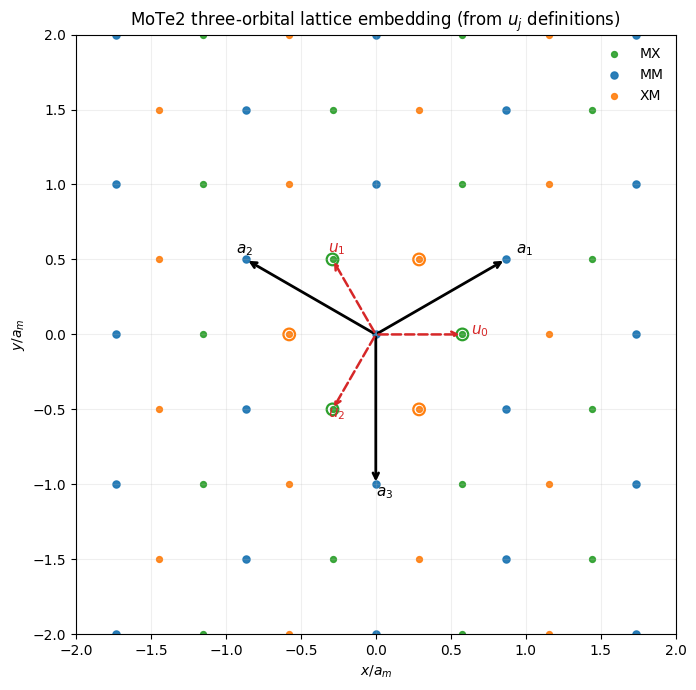

In [3]:
# Real-space lattice visualization with Fig. 2-style embedding.
from aidan_custom.mote2_three_orbital import _mote2_vectors

a1, a2, a3, _, u_vectors = _mote2_vectors(params["a_m"])
# Paper notation for bond vectors.
u0, u1, u2 = u_vectors

# Embedding tied to u-vectors:
# MM sits on triangular Bravais sites R,
# MX on R + u0, XM on R - u0.
# Then the nearest MX neighbors of MM are at u0,u1,u2 (up to Bravais translations).
r_mm = np.array([0.0, 0.0])
r_mx = u0
r_xm = -u0

n_range = np.arange(-4, 5, dtype=int)
pts_mm = np.empty((n_range.size * n_range.size, 2), dtype=float)
pts_mx = np.empty_like(pts_mm)
pts_xm = np.empty_like(pts_mm)

idx = 0
for n1 in n_range:
    for n2 in n_range:
        R = n1 * a1 + n2 * a2
        pts_mm[idx] = R + r_mm
        pts_mx[idx] = R + r_mx
        pts_xm[idx] = R + r_xm
        idx += 1

fig, ax = plt.subplots(figsize=(7.6, 7.0))
ax.scatter(pts_mx[:, 0], pts_mx[:, 1], s=18, c="#2ca02c", label="MX", alpha=0.90)
ax.scatter(pts_mm[:, 0], pts_mm[:, 1], s=26, c="#1f77b4", label="MM", alpha=0.95)
ax.scatter(pts_xm[:, 0], pts_xm[:, 1], s=18, c="#ff7f0e", label="XM", alpha=0.90)

# Draw primitive vectors a1,a2,a3 and bond vectors u0,u1,u2 from the origin MM site.
a_specs = [(a1, r"$a_1$"), (a2, r"$a_2$"), (a3, r"$a_3$")]
for vec, label in a_specs:
    ax.annotate(
        "",
        xy=(vec[0], vec[1]),
        xytext=(0.0, 0.0),
        arrowprops=dict(arrowstyle="->", color="black", lw=2.0),
        zorder=6,
    )
    ax.text(1.08 * vec[0], 1.08 * vec[1], label, color="black", fontsize=11, weight="bold")

u_specs = [(u0, r"$u_0$"), (u1, r"$u_1$"), (u2, r"$u_2$")]
for vec, label in u_specs:
    ax.annotate(
        "",
        xy=(vec[0], vec[1]),
        xytext=(0.0, 0.0),
        arrowprops=dict(arrowstyle="->", color="#d62728", lw=1.8, linestyle="--"),
        zorder=6,
    )
    ax.text(1.10 * vec[0], 1.10 * vec[1], label, color="#d62728", fontsize=11, weight="bold")

# Highlight the six nearest honeycomb sites around MM at origin.
near_mx = np.array([u0, u1, u2])
near_xm = -near_mx
ax.scatter(near_mx[:, 0], near_mx[:, 1], s=70, facecolors="none", edgecolors="#2ca02c", linewidths=1.6)
ax.scatter(near_xm[:, 0], near_xm[:, 1], s=70, facecolors="none", edgecolors="#ff7f0e", linewidths=1.6)

ax.set_aspect("equal")
ax.set_xlabel(r"$x/a_m$")
ax.set_ylabel(r"$y/a_m$")
ax.set_title("MoTe2 three-orbital lattice embedding (from $u_j$ definitions)")
ax.legend(frameon=False, loc="upper right")
ax.grid(alpha=0.2)
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.tight_layout()
plt.show()


/tmp/ipykernel_723365/881729228.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="best")


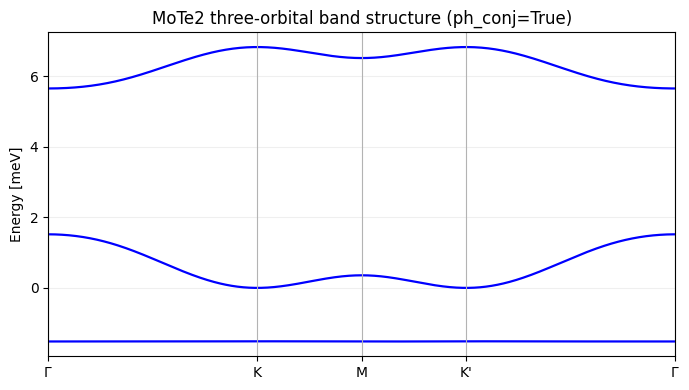

In [4]:
b1, b2 = mote2_three_orbital_reciprocal_vectors(a_m=params["a_m"])
k_path, x, x_nodes, labels = k_path_gamma_k_m_kp_gamma(180, b1, b2, fold=True)
bands = np.array([
    mote2_three_orbital_eigenvalues(kx, ky, ph_conj=ph_conj, **params)
    for kx, ky in k_path
])

fig, ax = plt.subplots(figsize=(7.0, 4.0))
for n in range(3):
    ax.plot(x, bands[:, n], lw=1.6,color="blue")
for xn in x_nodes:
    ax.axvline(xn, color="0.7", lw=0.8)
ax.set_xticks(x_nodes)
ax.set_xticklabels(labels)
ax.set_xlim(x[0], x[-1])
ax.set_ylabel("Energy [meV]")
ax.set_title(f"MoTe2 three-orbital band structure (ph_conj={ph_conj})")
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, loc="best")
plt.tight_layout()
plt.show()


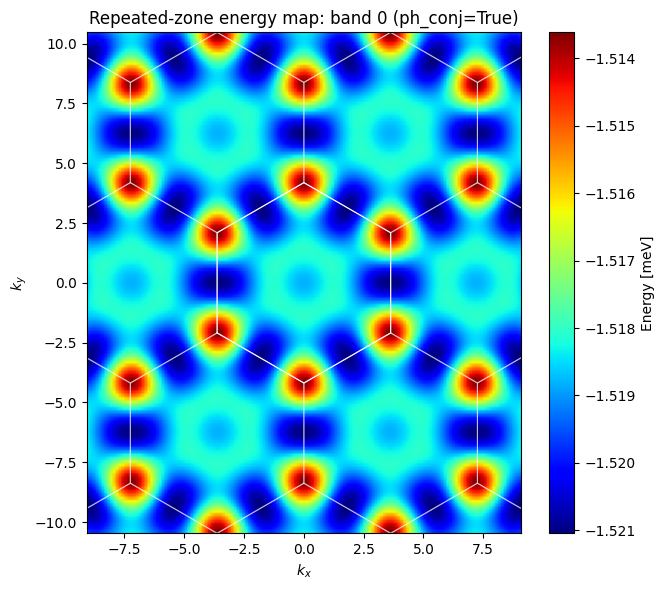

In [6]:
# Repeated-zone energy map for the first (lowest) band.
band_for_imshow = 0
n_kx = 151
n_ky = 151
zone_scale = 2.5  # Plot region extends beyond the first BZ in both directions.

bz_hex = first_bz_hexagon_vertices(b1, b2)
hex_closed = np.vstack((bz_hex, bz_hex[0]))
kx_half_span = zone_scale * np.max(np.abs(bz_hex[:, 0]))
ky_half_span = zone_scale * np.max(np.abs(bz_hex[:, 1]))

kx_vals = np.linspace(-kx_half_span, kx_half_span, n_kx)
ky_vals = np.linspace(-ky_half_span, ky_half_span, n_ky)
energy_map = np.empty((n_ky, n_kx), dtype=float)

eig_fn = mote2_three_orbital_eigenvalues
for iy, ky in enumerate(ky_vals):
    for ix, kx in enumerate(kx_vals):
        energy_map[iy, ix] = eig_fn(kx, ky, ph_conj=ph_conj, **params)[band_for_imshow]

fig, ax = plt.subplots(figsize=(6.8, 6.0))
im = ax.imshow(
    energy_map,
    origin="lower",
    extent=[kx_vals[0], kx_vals[-1], ky_vals[0], ky_vals[-1]],
    aspect="equal",
    cmap="jet",
)

# Overlay first-BZ boundaries translated by reciprocal lattice vectors.
for n1 in range(-2, 3):
    for n2 in range(-2, 3):
        shift = n1 * b1 + n2 * b2
        ax.plot(
            hex_closed[:, 0] + shift[0],
            hex_closed[:, 1] + shift[1],
            color="white",
            lw=0.8,
            alpha=0.5 if (n1, n2) != (0, 0) else 1.0,
        )

ax.set_xlim(kx_vals[0], kx_vals[-1])
ax.set_ylim(ky_vals[0], ky_vals[-1])

ax.set_xlabel(r"$k_x$")
ax.set_ylabel(r"$k_y$")
ax.set_title(f"Repeated-zone energy map: band {band_for_imshow} (ph_conj={ph_conj})")
fig.colorbar(im, ax=ax, label="Energy [meV]")
plt.tight_layout()
plt.show()


Estimated Chern number (band=lowest, ph_conj=True) = -1.0000000000
Estimated quantum weight (band=lowest, ph_conj=True) = 1.0019572060


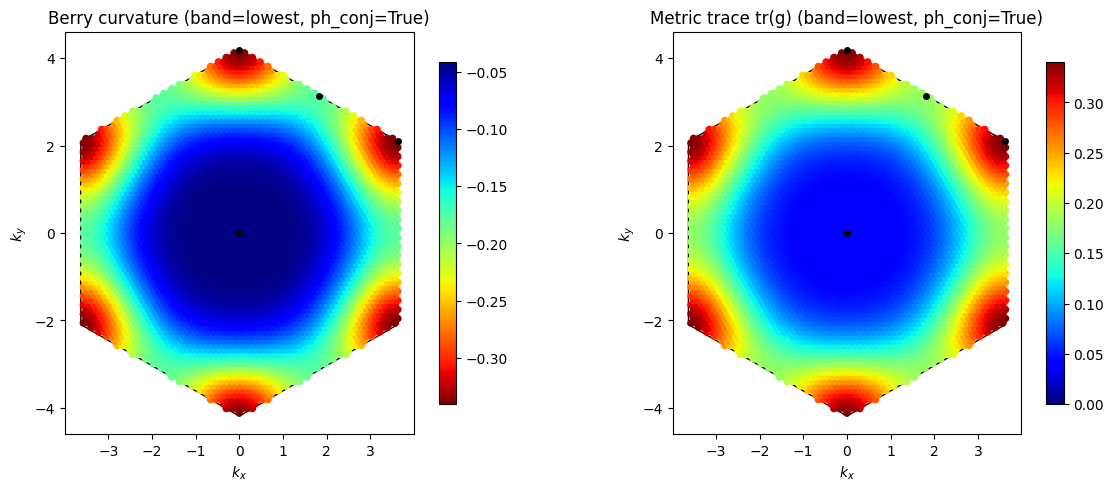

In [7]:
gamma, k_node, m_node, kp_node = high_symmetry_points(b1, b2)
bz_hex = first_bz_hexagon_vertices(b1, b2)

# Uniform mBZ quadrature for integrated Chern number and quantum weight.
bz_nx = 61
bz_ny = 61
k_points_all = sample_shortest_representative_bz(bz_nx, bz_ny, b1, b2, unique=False)
berry_all = np.empty(k_points_all.shape[0], dtype=float)
metric_trace_all = np.empty(k_points_all.shape[0], dtype=float)

for i, (kx, ky) in enumerate(k_points_all):
    berry_i, metric_i = mote2_three_orbital_berry_and_metric_trace(
        kx=kx,
        ky=ky,
        band=band_for_geometry,
        ph_conj=ph_conj,
        **params,
    )
    berry_all[i] = berry_i
    metric_trace_all[i] = metric_i

area_bz = abs(b1[0] * b2[1] - b1[1] * b2[0])
dk_area = area_bz / (bz_nx * bz_ny)
chern_number = (dk_area / (2.0 * np.pi)) * np.sum(berry_all)
quantum_weight = (dk_area / (2.0 * np.pi)) * np.sum(metric_trace_all)

print(f"Estimated Chern number (band={band_for_geometry}, ph_conj={ph_conj}) = {chern_number:.10f}")
print(f"Estimated quantum weight (band={band_for_geometry}, ph_conj={ph_conj}) = {quantum_weight:.10f}")

# Unique representatives for cleaner scatter visualization.
k_points = sample_shortest_representative_bz(bz_nx, bz_ny, b1, b2, unique=True)
berry = np.empty(k_points.shape[0], dtype=float)
metric_trace = np.empty(k_points.shape[0], dtype=float)

for i, (kx, ky) in enumerate(k_points):
    berry_i, metric_i = mote2_three_orbital_berry_and_metric_trace(
        kx=kx,
        ky=ky,
        band=band_for_geometry,
        ph_conj=ph_conj,
        **params,
    )
    berry[i] = berry_i
    metric_trace[i] = metric_i

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), constrained_layout=True)

hex_x = np.r_[bz_hex[:, 0], bz_hex[0, 0]]
hex_y = np.r_[bz_hex[:, 1], bz_hex[0, 1]]
special = np.array([gamma, k_node, m_node, kp_node])

sc0 = axes[0].scatter(k_points[:, 0], k_points[:, 1], c=berry, s=20, cmap="jet_r", clim=(-np.amax(np.abs(berry),0)))
axes[0].plot(hex_x, hex_y, color="black", lw=1.0, zorder=-1)
axes[0].scatter(special[:, 0], special[:, 1], color="black", s=16)
axes[0].set_aspect("equal")
axes[0].set_title(f"Berry curvature (band={band_for_geometry}, ph_conj={ph_conj})")
axes[0].set_xlabel(r"$k_x$")
axes[0].set_ylabel(r"$k_y$")
fig.colorbar(sc0, ax=axes[0], shrink=0.85)

sc1 = axes[1].scatter(k_points[:, 0], k_points[:, 1], c=metric_trace, s=20, cmap="jet", clim=(0, np.amax(metric_trace)))
axes[1].plot(hex_x, hex_y, color="black", lw=1.0, zorder=-1)
axes[1].scatter(special[:, 0], special[:, 1], color="black", s=16)
axes[1].set_aspect("equal")
axes[1].set_title(f"Metric trace tr(g) (band={band_for_geometry}, ph_conj={ph_conj})")
axes[1].set_xlabel(r"$k_x$")
axes[1].set_ylabel(r"$k_y$")
fig.colorbar(sc1, ax=axes[1], shrink=0.85)

plt.show()


In [8]:
chern = mote2_three_orbital_chern_numbers(nx=21, ny=21, ph_conj=ph_conj, **params)
print(f"Integrated Chern estimates (bands 0,1,2), ph_conj={ph_conj}:")
print(np.array2string(chern, precision=6, separator=", "))
print("Nearest integers:", np.rint(chern).astype(int))


Integrated Chern estimates (bands 0,1,2), ph_conj=True:
[-1.000000e+00,  1.000000e+00, -3.413281e-17]
Nearest integers: [-1  1  0]


In [ ]:
# Restored legacy parameter options.
# Option A: Eq. (2) parameters from Fig. 3b at theta = 3 deg (approximate, in meV).
params_theta3deg_meV = {
    "delta": 27.9,
    "ez": 0.0,
    "t_th1": 5.15,
    "t_hh1": 1.81,
    "t_th2": 0.07,
    "t_hh3": 0.43,
    "t_tt1": -0.46,
    "a_m": 1.0,
}

# Option B: previously used scaled parameter set.
params_prev_scaled = {
    "delta": 2.806,
    "ez": 0.0,
    "t_th1": 1.0,
    "t_hh1": 0.667,
    "t_th2": 0.004,
    "t_hh3": 0.101,
    "t_tt1": -0.109,
    "a_m": 1.0,
}

print("Restored: params_theta3deg_meV, params_prev_scaled")
